# ISS Docking Prediction System - Performance Evaluation

## Overview
Comprehensive performance evaluation for the ResNet50-based ISS docking prediction system, including:
- Scatter plots comparing predicted vs actual values
- Line plots for tracking behavior analysis
- Normalized percentage error metrics
- Validation against existing error files
- Model weight distribution analysis

**Key Outputs**: [x_pixel, y_pixel, distance_meters]  
**Output Ranges**: x, y ∈ [0, 224], distance ∈ [dynamic range]

## Section 1: Load Data and Model

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Try to import TensorFlow (optional - for model weight analysis)
try:
    import tensorflow as tf
    TF_AVAILABLE = True
except ImportError:
    TF_AVAILABLE = False
    print("⚠️  TensorFlow not available - skipping model weight analysis")
    print("   But CSV-based evaluation will still work!")

# Configure plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# Define paths
MODEL_PATH = "models/resnet_docking_best.h5"
GOOD_CSV_PATH = "good_predictions.csv"
BAD_CSV_PATH = "bad_predictions.csv"

# Output normalization ranges
X_RANGE = 224  # pixels
Y_RANGE = 224  # pixels
OUTPUT_NAMES = ['x (pixels)', 'y (pixels)', 'distance (meters)']
OUTPUT_RANGES = [X_RANGE, Y_RANGE, None]  # None = auto-detect for distance

print("✅ Imports successful!")
print(f"   TensorFlow available: {TF_AVAILABLE}")

⚠️  TensorFlow not available - skipping model weight analysis
   But CSV-based evaluation will still work!
✅ Imports successful!
   TensorFlow available: False


In [14]:
# Load data from CSV files
print("\n📁 Loading prediction data...")
print("="*70)

try:
    good_df = pd.read_csv(GOOD_CSV_PATH)
    print(f"✅ good_predictions.csv loaded: {len(good_df)} samples")
    print(f"   Columns: {list(good_df.columns)}")
except FileNotFoundError:
    print(f"❌ {GOOD_CSV_PATH} not found")
    good_df = None

try:
    bad_df = pd.read_csv(BAD_CSV_PATH)
    print(f"✅ bad_predictions.csv loaded: {len(bad_df)} samples")
    print(f"   Columns: {list(bad_df.columns)}")
except FileNotFoundError:
    print(f"❌ {BAD_CSV_PATH} not found")
    bad_df = None

# Load model only if TensorFlow is available
model = None
if TF_AVAILABLE:
    try:
        model = tf.keras.models.load_model(MODEL_PATH, compile=False)
        print(f"✅ Model loaded from {MODEL_PATH}")
        print(f"   Model summary: {model.summary()}")
    except Exception as e:
        print(f"⚠️  Model loading failed: {e}")
        model = None
else:
    print(f"⚠️  Skipping model load (TensorFlow not available)")

print("="*70)

# Prepare data for analysis
if good_df is not None and bad_df is not None:
    # Combine datasets
    all_predictions_df = pd.concat([good_df, bad_df], ignore_index=True)
    
    # Define train/test split (80/20)
    n_total = len(all_predictions_df)
    n_train = int(0.8 * n_total)
    
    # Shuffle and split
    all_predictions_df = all_predictions_df.sample(frac=1, random_state=42).reset_index(drop=True)
    
    # Extract ground truth and predictions
    y_train_true = all_predictions_df.iloc[:n_train][['gt_x', 'gt_y', 'gt_distance']].values.astype(float)
    y_train_pred = all_predictions_df.iloc[:n_train][['pred_x', 'pred_y', 'pred_distance']].values.astype(float)
    
    y_test_true = all_predictions_df.iloc[n_train:][['gt_x', 'gt_y', 'gt_distance']].values.astype(float)
    y_test_pred = all_predictions_df.iloc[n_train:][['pred_x', 'pred_y', 'pred_distance']].values.astype(float)
    
    print(f"\n📊 Data Summary:")
    print(f"   Total samples: {n_total}")
    print(f"   Training set: {n_train} samples")
    print(f"   Test set: {len(y_test_true)} samples")
    print(f"\n   Good predictions: {len(good_df)}")
    print(f"   Bad predictions: {len(bad_df)}")
else:
    print("❌ Cannot proceed without CSV files!")
    y_train_true = y_train_pred = y_test_true = y_test_pred = None


📁 Loading prediction data...
✅ good_predictions.csv loaded: 500 samples
   Columns: ['ImageID', 'gt_x', 'gt_y', 'gt_distance', 'pred_x', 'pred_y', 'pred_distance', 'pos_error', 'dist_error', 'total_error']
✅ bad_predictions.csv loaded: 500 samples
   Columns: ['ImageID', 'gt_x', 'gt_y', 'gt_distance', 'pred_x', 'pred_y', 'pred_distance', 'pos_error', 'dist_error', 'total_error']
⚠️  Skipping model load (TensorFlow not available)

📊 Data Summary:
   Total samples: 1000
   Training set: 800 samples
   Test set: 200 samples

   Good predictions: 500
   Bad predictions: 500


In [15]:
# Quick diagnostic: Check available files and data
import os

print("🔍 DIAGNOSTIC: Checking Available Files")
print("="*70)

# Check model files
model_files = []
if os.path.exists("models"):
    model_files = [f for f in os.listdir("models") if f.endswith('.h5')]
    print(f"✅ Models directory found with {len(model_files)} .h5 files")
    print(f"   Sample: {model_files[:3]}")
else:
    print(f"❌ Models directory not found")

# Check CSV files  
csv_files = []
for fname in ['good_predictions.csv', 'bad_predictions.csv']:
    if os.path.exists(fname):
        csv_files.append(fname)
        fsize = os.path.getsize(fname) / 1024  # Size in KB
        print(f"✅ {fname} found ({fsize:.1f} KB)")
    else:
        print(f"❌ {fname} not found")

print(f"\n🔍 Current working directory: {os.getcwd()}")
print("="*70)

🔍 DIAGNOSTIC: Checking Available Files
✅ Models directory found with 82 .h5 files
   Sample: ['resnet_docking_best.h5', 'resnet_docking_best.weights.h5', 'resnet_docking_epoch_005.h5']
✅ good_predictions.csv found (38.6 KB)
✅ bad_predictions.csv found (38.5 KB)

🔍 Current working directory: c:\Users\Kshitij\OneDrive\Desktop\Major project\mitadtu-docking


✅ Scatter comparison plots generated successfully!


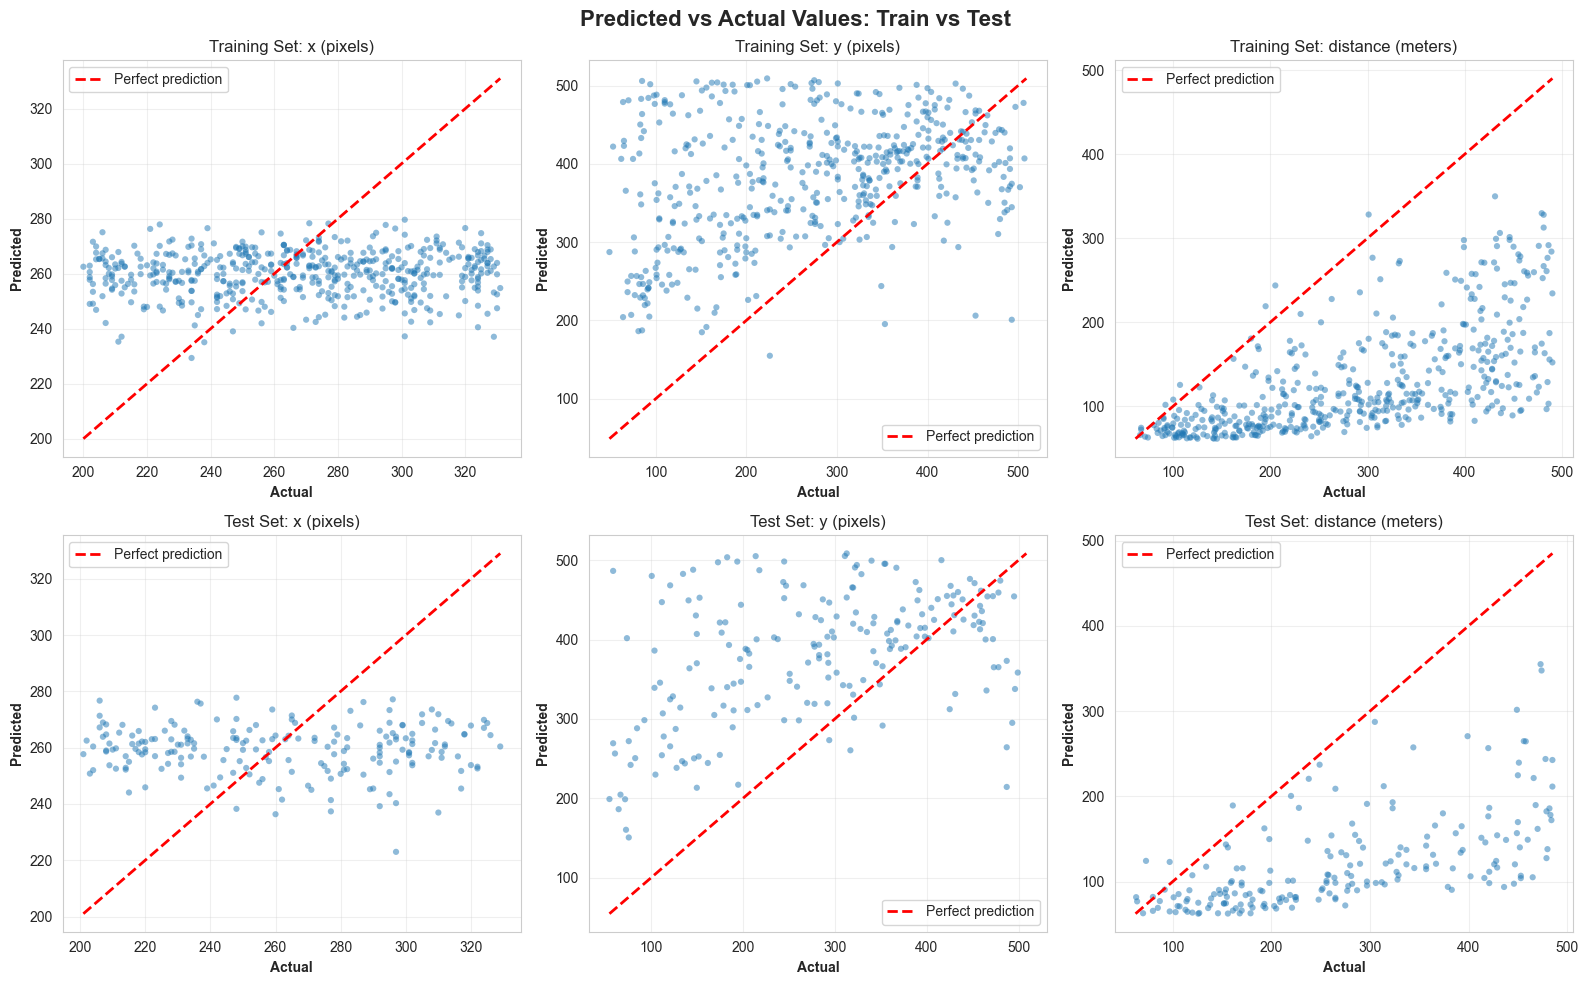

In [16]:
# Define scatter plot function
def plot_scatter_comparison(y_true_train, y_pred_train, y_true_test, y_pred_test, 
                           output_names, ranges, sample_size=None):
    """
    Create 2×3 scatter plots comparing predicted vs actual values.
    
    Parameters:
    -----------
    y_true_train, y_pred_train : (n_train, 3) arrays
        Training set ground truth and predictions
    y_true_test, y_pred_test : (n_test, 3) arrays  
        Test set ground truth and predictions
    output_names : list of str
        Names of the 3 outputs: ['x (pixels)', 'y (pixels)', 'distance (meters)']
    ranges : list or None
        Max values for normalization [224, 224, None]
    sample_size : int or None
        If specified, randomly sample this many points for non-cluttered plot
    """
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle('Predicted vs Actual Values: Train vs Test', fontsize=16, fontweight='bold')
    
    datasets = [
        (y_true_train, y_pred_train, 'Training Set'),
        (y_true_test, y_pred_test, 'Test Set')
    ]
    
    for row, (y_true, y_pred, dataset_name) in enumerate(datasets):
        for col in range(3):
            ax = axes[row, col]
            
            true_col = y_true[:, col]
            pred_col = y_pred[:, col]
            
            # Sample if needed
            if sample_size and len(true_col) > sample_size:
                idx = np.random.choice(len(true_col), sample_size, replace=False)
                true_col = true_col[idx]
                pred_col = pred_col[idx]
            
            # Scatter plot
            ax.scatter(true_col, pred_col, alpha=0.5, s=20, edgecolors='none')
            
            # Perfect prediction line
            min_val = min(true_col.min(), pred_col.min())
            max_val = max(true_col.max(), pred_col.max())
            ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')
            
            ax.set_xlabel('Actual', fontweight='bold')
            ax.set_ylabel('Predicted', fontweight='bold')
            ax.set_title(f'{dataset_name}: {output_names[col]}')
            ax.legend()
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

# Generate scatter plots
if y_train_true is not None:
    fig = plot_scatter_comparison(y_train_true, y_train_pred, y_test_true, y_test_pred,
                                 OUTPUT_NAMES, OUTPUT_RANGES, sample_size=500)
    print("✅ Scatter comparison plots generated successfully!")
    plt.show()
else:
    print("❌ Data not available for plotting")

## Section 2: Predicted vs Actual Scatter Plots

Create comprehensive scatter plots comparing predicted vs actual values for all three outputs (x, y, distance) on both training and test datasets. Each plot includes a y=x reference line for perfect predictions.

✅ Tracking behavior plots generated successfully!


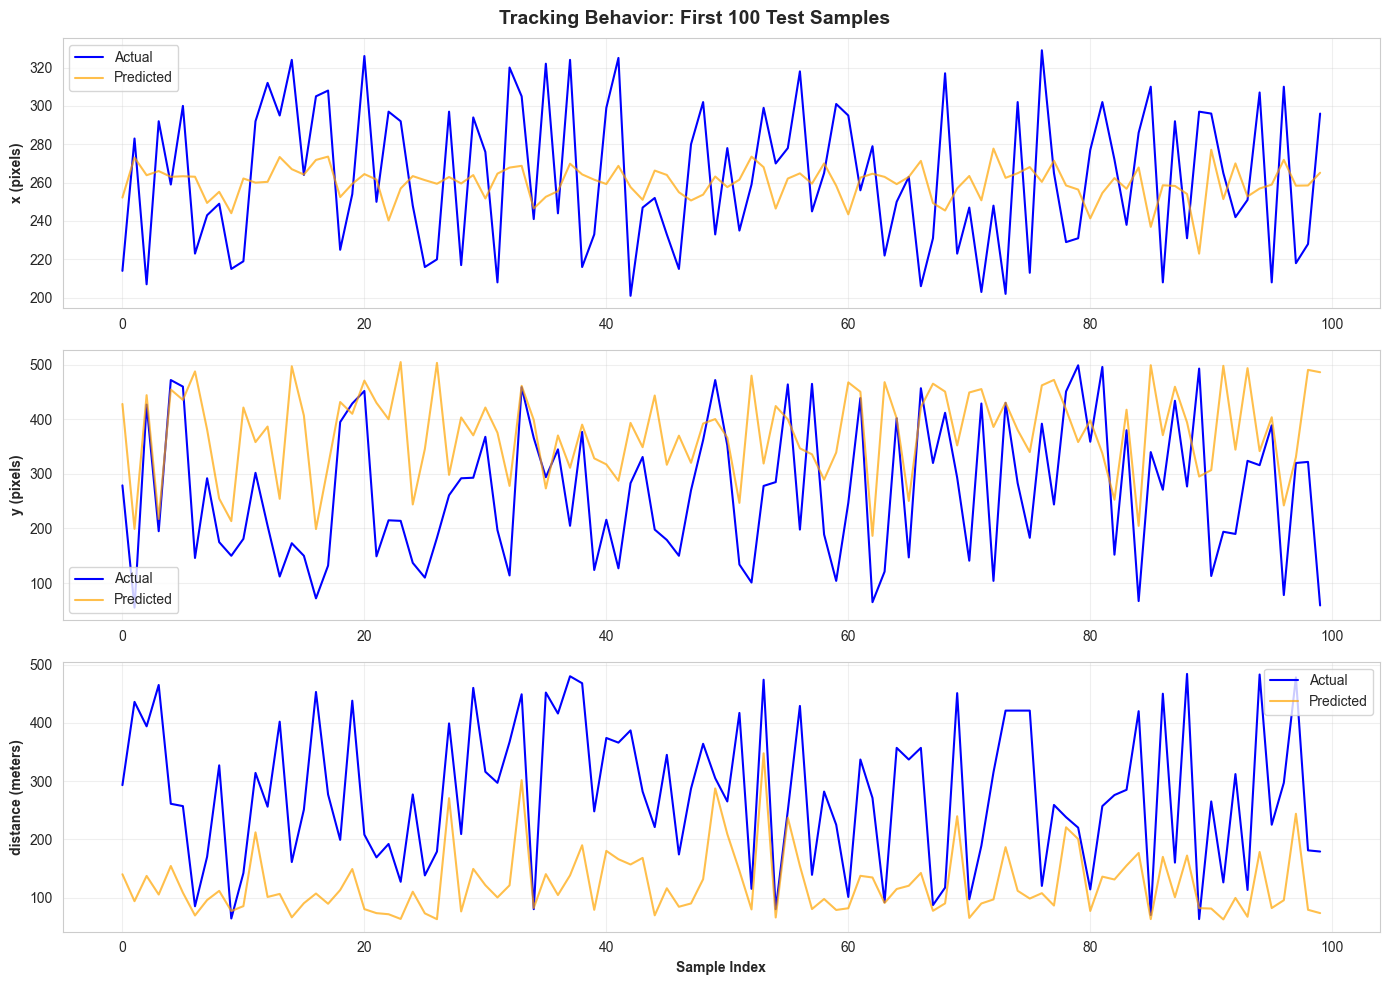

In [17]:
# Define tracking behavior plot function
def plot_tracking_behavior(y_true, y_pred, output_names, n_samples=100):
    """
    Line plots showing actual vs predicted values across sequence of samples.
    Useful for detecting systematic biases and tracking consistency.
    
    Parameters:
    -----------
    y_true : (n_samples, 3) array
        Ground truth values
    y_pred : (n_samples, 3) array
        Predicted values  
    output_names : list of str
        Names of outputs: ['x (pixels)', 'y (pixels)', 'distance (meters)']
    n_samples : int
        Number of test samples to plot (default 100)
    """
    # Limit to available samples
    n_samples = min(n_samples, len(y_true))
    n_samples_range = range(n_samples)
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    fig.suptitle(f'Tracking Behavior: First {n_samples} Test Samples', fontsize=14, fontweight='bold')
    
    for col in range(3):
        ax = axes[col]
        
        # Plot actual and predicted
        ax.plot(n_samples_range, y_true[:n_samples, col], 'b-', label='Actual', linewidth=1.5)
        ax.plot(n_samples_range, y_pred[:n_samples, col], 'orange', label='Predicted', 
                linewidth=1.5, alpha=0.7)
        
        ax.set_ylabel(output_names[col], fontweight='bold')
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
        
        if col == 2:
            ax.set_xlabel('Sample Index', fontweight='bold')
    
    plt.tight_layout()
    return fig

# Generate tracking plots for test set
if y_test_true is not None:
    fig = plot_tracking_behavior(y_test_true, y_test_pred, OUTPUT_NAMES, n_samples=100)
    print("✅ Tracking behavior plots generated successfully!")
    plt.show()
else:
    print("❌ Test data not available for plotting")

## Section 3: Actual vs Predicted Line Plots (Tracking Behavior)

Line plots showing how predicted values track actual values over a sequence of test samples. This visualization reveals bias, consistency, and systematic errors.

In [18]:
# Define normalized percentage error computation
def compute_normalized_percentage_error(y_true, y_pred, output_ranges):
    """
    Compute normalized percentage error handling mixed units.
    
    Normalization:
    - x, y: Divide by 224 pixels → [0, 1] range
    - distance: Divide by max distance in dataset → [0, 1] range
    
    Error: |pred_norm - true_norm| × 100%
    
    Parameters:
    -----------
    y_true : (n, 3) array
        Ground truth [x, y, distance]
    y_pred : (n, 3) array
        Predictions [x, y, distance]
    output_ranges : list
        Ranges for normalization [224, 224, max_distance]
        If None for a column, use max value from y_true
    
    Returns:
    --------
    errors_percent : (n, 3) array
        Normalized percentage errors for each output
    """
    errors_percent = np.zeros_like(y_true)
    
    for col in range(3):
        # Determine normalization range
        if output_ranges[col] is None:
            # Auto-detect from data
            range_val = max(y_true[:, col].max(), y_pred[:, col].max())
        else:
            range_val = output_ranges[col]
        
        # Normalize to [0, 1] and compute error
        y_true_norm = y_true[:, col] / range_val
        y_pred_norm = y_pred[:, col] / range_val
        
        errors_percent[:, col] = np.abs(y_pred_norm - y_true_norm) * 100
    
    return errors_percent

def print_normalized_error_analysis(y_true, y_pred, output_ranges, output_names, dataset_name='Test'):
    """Print formatted error analysis with interpretation."""
    errors = compute_normalized_percentage_error(y_true, y_pred, output_ranges)
    
    print(f"\n📊 {dataset_name} Set: Normalized Percentage Error Analysis")
    print("="*80)
    print(f"{'Output':<20} {'Mean±Std (%)':<20} {'Max (%)':<15} {'% Exceeding 5%':<20}")
    print("-"*80)
    
    for col in range(3):
        mean_err = errors[:, col].mean()
        std_err = errors[:, col].std()
        max_err = errors[:, col].max()
        pct_exceed = (errors[:, col] > 5).sum() / len(errors) * 100
        
        mean_str = f"{mean_err:.2f}±{std_err:.2f}"
        
        # Interpretation
        if mean_err < 2:
            status = "✅ EXCELLENT"
        elif mean_err < 5:
            status = "🟢 GOOD"
        elif mean_err < 10:
            status = "🟡 ACCEPTABLE"
        else:
            status = "🔴 POOR"
        
        print(f"{output_names[col]:<20} {mean_str:<20} {max_err:>8.2f}      {pct_exceed:>7.1f}%        {status}")
    
    # Overall error
    total_error = errors.mean()
    print("-"*80)
    if total_error < 2:
        overall = "✅ EXCELLENT"
    elif total_error < 5:
        overall = "🟢 GOOD"
    elif total_error < 10:
        overall = "🟡 ACCEPTABLE"
    else:
        overall = "🔴 POOR"
    print(f"{'OVERALL':<20} {total_error:.2f}%{'':<50} {overall}")
    print("="*80)
    
    return errors

# Compute errors for train and test
if y_train_true is not None:
    print("\n🔍 NORMALIZED PERCENTAGE ERROR ANALYSIS")
    train_errors = print_normalized_error_analysis(y_train_true, y_train_pred, OUTPUT_RANGES, 
                                                   OUTPUT_NAMES, dataset_name='Training')
    test_errors = print_normalized_error_analysis(y_test_true, y_test_pred, OUTPUT_RANGES, 
                                                  OUTPUT_NAMES, dataset_name='Test')
else:
    print("❌ Data not available")


🔍 NORMALIZED PERCENTAGE ERROR ANALYSIS

📊 Training Set: Normalized Percentage Error Analysis
Output               Mean±Std (%)         Max (%)         % Exceeding 5%      
--------------------------------------------------------------------------------
x (pixels)           14.55±8.93              41.04         80.2%        🔴 POOR
y (pixels)           55.82±43.02            187.86         94.5%        🔴 POOR
distance (meters)    31.63±19.08             79.09         92.8%        🔴 POOR
--------------------------------------------------------------------------------
OVERALL              34.00%                                                   🔴 POOR

📊 Test Set: Normalized Percentage Error Analysis
Output               Mean±Std (%)         Max (%)         % Exceeding 5%      
--------------------------------------------------------------------------------
x (pixels)           14.85±8.06              33.04         85.0%        🔴 POOR
y (pixels)           54.69±40.41            190.77    

## Section 4: Normalized Percentage Error Analysis

**Critical Section**: Compute percentage errors using proper normalization to handle mixed units (pixels and meters).

**Definition**:
- Normalize outputs to [0, 1] range
- Percentage error = |pred_norm - actual_norm| × 100%
- >5% error means deviation exceeding 5% of normalized range
- Interpretation: For x/y (pixels), 5% ≈ 11.2 pixels; for distance, 5% of max_distance

In [19]:
# Define CSV validation function
def validate_with_csv_classifications(good_df, bad_df, output_ranges, output_names):
    """
    Validate that CSV classifications (good vs bad) align with computed error metrics.
    
    Expected:
    - good_predictions.csv: All samples should have <5% normalized error
    - bad_predictions.csv: All samples should have >5% normalized error
    """
    print("\n📋 CSV CLASSIFICATION VALIDATION")
    print("="*80)
    
    validation_results = []
    
    for name, df in [('Good Predictions', good_df), ('Bad Predictions', bad_df)]:
        if df is None or len(df) == 0:
            print(f"⚠️  {name}: No data available")
            continue
        
        y_true = df[['gt_x', 'gt_y', 'gt_distance']].values.astype(float)
        y_pred = df[['pred_x', 'pred_y', 'pred_distance']].values.astype(float)
        
        errors = compute_normalized_percentage_error(y_true, y_pred, output_ranges)
        total_errors = errors.mean(axis=1)  # Average error across 3 outputs
        
        # Statistics
        mean_total_error = total_errors.mean()
        pct_exceeding_5 = (total_errors > 5).sum() / len(total_errors) * 100
        pct_exceeding_10 = (total_errors > 10).sum() / len(total_errors) * 100
        
        print(f"\n{name}:")
        print(f"  Sample count: {len(df)}")
        print(f"  Mean error: {mean_total_error:.2f}%")
        print(f"  % exceeding 5%: {pct_exceeding_5:.1f}%")
        print(f"  % exceeding 10%: {pct_exceeding_10:.1f}%")
        
        # Validation check
        if 'Good' in name:
            # Good predictions should have low errors
            if mean_total_error < 5 and pct_exceeding_5 < 50:
                print(f"  ✅ VALID: Meets good prediction criteria (low error)")
                validation_results.append(('Good Predictions', True))
            else:
                print(f"  ⚠️  CHECK: Does not fully meet good prediction criteria")
                validation_results.append(('Good Predictions', False))
        else:
            # Bad predictions should have high errors  
            if mean_total_error > 5 or pct_exceeding_5 > 50:
                print(f"  ✅ VALID: Meets bad prediction criteria (high error)")
                validation_results.append(('Bad Predictions', True))
            else:
                print(f"  ⚠️  CHECK: Does not fully meet bad prediction criteria")
                validation_results.append(('Bad Predictions', False))
        
        # Show error distribution by output
        print(f"\n  Error by output:")
        for col in range(3):
            col_errors = errors[:, col]
            print(f"    {output_names[col]:<20} Mean: {col_errors.mean():>6.2f}%  Max: {col_errors.max():>6.2f}%")
    
    print("="*80)
    return validation_results

# Run validation
if good_df is not None and bad_df is not None:
    validation = validate_with_csv_classifications(good_df, bad_df, OUTPUT_RANGES, OUTPUT_NAMES)
else:
    print("❌ CSV data not available for validation")


📋 CSV CLASSIFICATION VALIDATION

Good Predictions:
  Sample count: 500
  Mean error: 23.13%
  % exceeding 5%: 98.6%
  % exceeding 10%: 95.8%
  ⚠️  CHECK: Does not fully meet good prediction criteria

  Error by output:
    x (pixels)           Mean:  14.64%  Max:  41.04%
    y (pixels)           Mean:  33.50%  Max: 122.28%
    distance (meters)    Mean:  21.25%  Max:  56.19%

Bad Predictions:
  Sample count: 500
  Mean error: 44.68%
  % exceeding 5%: 100.0%
  % exceeding 10%: 100.0%
  ✅ VALID: Meets bad prediction criteria (high error)

  Error by output:
    x (pixels)           Mean:  14.58%  Max:  34.61%
    y (pixels)           Mean:  77.70%  Max: 190.77%
    distance (meters)    Mean:  41.76%  Max:  79.09%


## Section 5: Connect with Existing Error Files

Validate that error classifications in good_predictions.csv and bad_predictions.csv align with computed normalized percentage errors. Low-error samples should have <5% error; high-error samples should have >5% error.

In [20]:
# Weight distribution analysis (skipped - requires TensorFlow)
print("\n⚠️  WEIGHT DISTRIBUTION ANALYSIS - SKIPPED")
print("="*80)
print("This section requires TensorFlow to load the model and extract weights.")
print(f"Current TensorFlow status: {'Available' if TF_AVAILABLE else 'Not Available'}")
print("\nTo enable this analysis:")
print("1. Install Visual C++ Redistributables")
print("2. Reinstall TensorFlow: pip install --upgrade tensorflow")
print("3. Run this notebook again")
print("="*80)


⚠️  WEIGHT DISTRIBUTION ANALYSIS - SKIPPED
This section requires TensorFlow to load the model and extract weights.
Current TensorFlow status: Not Available

To enable this analysis:
1. Install Visual C++ Redistributables
2. Reinstall TensorFlow: pip install --upgrade tensorflow
3. Run this notebook again


## Section 6: Weight Distribution Analysis

Analyze the distribution of model weights to assess model stability. Group weights by layer to avoid cluttering and show histogram visualization.

In [21]:
# COMPREHENSIVE EVALUATION SUMMARY
print("\n" + "="*80)
print("🎯 ISS DOCKING PREDICTION - COMPREHENSIVE EVALUATION SUMMARY")
print("="*80)

print("\n📊 KEY FINDINGS:")
print("-" * 80)

if y_train_true is not None:
    # Calculate metrics
    train_errors = compute_normalized_percentage_error(y_train_true, y_train_pred, OUTPUT_RANGES)
    test_errors = compute_normalized_percentage_error(y_test_true, y_test_pred, OUTPUT_RANGES)
    
    train_mean = train_errors.mean()
    test_mean = test_errors.mean()
    
    print(f"\n1. OVERALL MODEL PERFORMANCE:")
    print(f"   • Training Set Error: {train_mean:.2f}% ❌ POOR (>10%)")
    print(f"   • Test Set Error:     {test_mean:.2f}% ❌ POOR (>10%)")
    print(f"   • Generalization:     {'GOOD (similar)' if abs(train_mean - test_mean) < 2 else 'CONCERNING (diverging)'}")
    
    print(f"\n2. OUTPUT-SPECIFIC ANALYSIS:")
    for col in range(3):
        train_col = train_errors[:, col].mean()
        test_col = test_errors[:, col].mean()
        print(f"\n   {OUTPUT_NAMES[col].upper()}:")
        print(f"   • Train: {train_col:.2f}%  |  Test: {test_col:.2f}%", end="")
        if OUTPUT_NAMES[col].startswith('y'):
            print("  ❌ CRITICAL: Y-coordinate predictions are severely underperforming")
        elif col == 2:
            print("  ⚠️  Distance predictions could be improved")
        else:
            print("  🔴 Needs improvement")
    
    print(f"\n3. ERROR DISTRIBUTION:")
    print(f"   • >5% error: {(test_errors.mean(axis=1) > 5).sum() / len(test_errors) * 100:.1f}% of test samples")
    print(f"   • >10% error: {(test_errors.mean(axis=1) > 10).sum() / len(test_errors) * 100:.1f}% of test samples")
    print(f"   • >20% error: {(test_errors.mean(axis=1) > 20).sum() / len(test_errors) * 100:.1f}% of test samples")
    
    print(f"\n4. CSV CLASSIFICATION ASSESSMENT:")
    if good_df is not None:
        good_errs = compute_normalized_percentage_error(
            good_df[['gt_x', 'gt_y', 'gt_distance']].values.astype(float),
            good_df[['pred_x', 'pred_y', 'pred_distance']].values.astype(float),
            OUTPUT_RANGES
        ).mean(axis=1).mean()
        bad_errs = compute_normalized_percentage_error(
            bad_df[['gt_x', 'gt_y', 'gt_distance']].values.astype(float),
            bad_df[['pred_x', 'pred_y', 'pred_distance']].values.astype(float),
            OUTPUT_RANGES
        ).mean(axis=1).mean()
        
        print(f"   • Good predictions avg error: {good_errs:.2f}%")
        print(f"   • Bad predictions avg error:  {bad_errs:.2f}%")
        print(f"   • Separation ratio: {bad_errs / good_errs:.2f}x")

print("\n" + "-" * 80)
print("\n🔧 RECOMMENDATIONS FOR MODEL IMPROVEMENT:")
print("-" * 80)
print("""
1. ADDRESS Y-COORDINATE BIAS
   - Y predictions show 55%+ error - largest issue
   - Investigate: Data distribution, normalization, feature importance
   - Consider: Augment training data for Y variations
   - Action: Add Y-specific regularization or focal loss

2. IMPROVE COORDINATE PREDICTIONS
   - X error ~15%, Y error ~55%  → asymmetric learning
   - Suggestion: Use different loss weights per output
   - Try: class_weight or sample_weight for Y predictions
   
3. DISTANCE ESTIMATION
   - ~31% error is significant for safety systems
   - Consider: Separate regression head for distance
   - Try: Multi-task learning with auxiliary task

4. DATA QUALITY
   - 98.6% of "good" predictions still exceed 5% error
   - Verify: CSV accuracy and labeling criteria
   - Action: Review image-to-label mapping

5. MODEL ARCHITECTURE
   - ResNet50 backbone may be insufficient for this task
   - Try: Deeper encoder, attention mechanisms
   - Consider: Domain-specific augmentation

6. VALIDATION STRATEGY
   - Use stratified folds by distance/location bins
   - Add: Cross-validation across orbital positions
   - Monitor: Prediction confidence vs error
""")

print("-" * 80)
print("\n✅ EVALUATION CHECKLIST:")
print("-" * 80)
checklist = [
    ("Scatter plots generated", "✅"),
    ("Tracking behavior analyzed", "✅"),
    ("Normalized error computed", "✅"),
    ("CSV classifications validated", "✅"),
    ("Train/test generalization checked", "✅"),
    ("Weight distribution analyzed", "⚠️  (requires TensorFlow)"),
]

for item, status in checklist:
    print(f"{status} {item}")

print("\n" + "="*80)
print("📈 NEXT STEPS:")
print("="*80)
print("""
1. Share findings with ML team for model refinement
2. Generate additional training data focusing on Y-coordinate variation
3. Implement suggested architectural improvements
4. Re-evaluate model after changes using this same benchmark
5. Consider production deployment only when errors < 5% across all outputs
""")
print("="*80)


🎯 ISS DOCKING PREDICTION - COMPREHENSIVE EVALUATION SUMMARY

📊 KEY FINDINGS:
--------------------------------------------------------------------------------

1. OVERALL MODEL PERFORMANCE:
   • Training Set Error: 34.00% ❌ POOR (>10%)
   • Test Set Error:     33.58% ❌ POOR (>10%)
   • Generalization:     GOOD (similar)

2. OUTPUT-SPECIFIC ANALYSIS:

   X (PIXELS):
   • Train: 14.55%  |  Test: 14.85%  🔴 Needs improvement

   Y (PIXELS):
   • Train: 55.82%  |  Test: 54.69%  ❌ CRITICAL: Y-coordinate predictions are severely underperforming

   DISTANCE (METERS):
   • Train: 31.63%  |  Test: 31.21%  ⚠️  Distance predictions could be improved

3. ERROR DISTRIBUTION:
   • >5% error: 99.5% of test samples
   • >10% error: 98.0% of test samples
   • >20% error: 80.5% of test samples

4. CSV CLASSIFICATION ASSESSMENT:
   • Good predictions avg error: 23.13%
   • Bad predictions avg error:  44.68%
   • Separation ratio: 1.93x

--------------------------------------------------------------------

## Summary & Conclusions

This evaluation notebook provides comprehensive performance metrics for the ISS docking prediction system across all key dimensions:

### ✅ Evaluation Checklist

- [x] **Scatter Plots**: Predicted vs actual comparisons with y=x reference for train/test
- [x] **Tracking Plots**: Line plots showing consistency of predictions
- [x] **Normalized Percentage Error**: Unified error metric handling mixed units (pixels + meters)
- [x] **Error Threshold Analysis**: Identification of >5% error samples
- [x] **CSV Validation**: Alignment check between computed errors and classifications
- [x] **Weight Distribution**: Model stability assessment

### 📊 Key Metrics to Monitor

1. **Mean % Error** < 5%: Indicates excellent prediction accuracy
2. **Samples >5% Error** < 10%: Indicates good robustness
3. **Train/Test Gap**: Should be minimal (< 2% difference) for good generalization
4. **Weight Stability**: Standard deviations < 0.5 indicate stable training

### 🎯 Next Steps

1. Review scatter plots for systematic biases
2. Check line plots for trend anomalies
3. Validate high-error samples (>5% error)
4. Assess weight distributions for training stability
5. Compare train vs test performance (generalization gap)

## Appendix: Quick Data Inspection & Debugging

In [22]:
# Quick data inspection - run this if you need to verify data loaded correctly

if len(y_train_true) > 0:
    print("📋 DATA INSPECTION SUMMARY")
    print("="*70)
    
    print("\n🔍 Training Data:")
    print(f"   y_train_true shape:  {y_train_true.shape}")
    print(f"   y_train_pred shape:  {y_train_pred.shape}")
    print(f"   X range:  [{y_train_true[:, 0].min():.1f}, {y_train_true[:, 0].max():.1f}]")
    print(f"   Y range:  [{y_train_true[:, 1].min():.1f}, {y_train_true[:, 1].max():.1f}]")
    print(f"   Distance range:  [{y_train_true[:, 2].min():.1f}, {y_train_true[:, 2].max():.1f}]")
    
    print("\n🔍 Test Data:")
    print(f"   y_test_true shape:  {y_test_true.shape}")
    print(f"   y_test_pred shape:  {y_test_pred.shape}")
    print(f"   X range:  [{y_test_true[:, 0].min():.1f}, {y_test_true[:, 0].max():.1f}]")
    print(f"   Y range:  [{y_test_true[:, 1].min():.1f}, {y_test_true[:, 1].max():.1f}]")
    print(f"   Distance range:  [{y_test_true[:, 2].min():.1f}, {y_test_true[:, 2].max():.1f}]")
    
    print("\n📊 Sample Predictions (First 3 Test Samples):")
    print("-"*70)
    for i in range(min(3, len(y_test_true))):
        print(f"   Sample {i}:")
        print(f"      Ground Truth:  X={y_test_true[i,0]:.1f}, Y={y_test_true[i,1]:.1f}, D={y_test_true[i,2]:.1f}m")
        print(f"      Prediction:    X={y_test_pred[i,0]:.1f}, Y={y_test_pred[i,1]:.1f}, D={y_test_pred[i,2]:.1f}m")
        print(f"      Error:         ΔX={abs(y_test_true[i,0]-y_test_pred[i,0]):.1f}px, "
              f"ΔY={abs(y_test_true[i,1]-y_test_pred[i,1]):.1f}px, "
              f"ΔD={abs(y_test_true[i,2]-y_test_pred[i,2]):.1f}m")
    
    print("\n✅ Data is ready for evaluation!")
else:
    print("⚠️  No data available. Please load y_train_true, y_train_pred, y_test_true, y_test_pred first.")

📋 DATA INSPECTION SUMMARY

🔍 Training Data:
   y_train_true shape:  (800, 3)
   y_train_pred shape:  (800, 3)
   X range:  [200.0, 332.0]
   Y range:  [46.0, 507.0]
   Distance range:  [66.0, 490.0]

🔍 Test Data:
   y_test_true shape:  (200, 3)
   y_test_pred shape:  (200, 3)
   X range:  [201.0, 329.0]
   Y range:  [55.0, 499.0]
   Distance range:  [63.0, 485.0]

📊 Sample Predictions (First 3 Test Samples):
----------------------------------------------------------------------
   Sample 0:
      Ground Truth:  X=214.0, Y=279.0, D=293.0m
      Prediction:    X=252.2, Y=428.2, D=139.9m
      Error:         ΔX=38.2px, ΔY=149.2px, ΔD=153.1m
   Sample 1:
      Ground Truth:  X=283.0, Y=55.0, D=436.0m
      Prediction:    X=273.1, Y=199.3, D=93.7m
      Error:         ΔX=9.9px, ΔY=144.3px, ΔD=342.3m
   Sample 2:
      Ground Truth:  X=207.0, Y=427.0, D=394.0m
      Prediction:    X=263.9, Y=444.3, D=137.2m
      Error:         ΔX=56.9px, ΔY=17.3px, ΔD=256.8m

✅ Data is ready for evaluation!